In [ ]:
import torch
from copy import deepcopy
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import torch.optim as optim
import numpy as np
import random
from tqdm import tqdm
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

## 1 Dataloader

In [2]:
def get_loaders(dataset_type, batch_size=64, valid_ratio=0.1):
    if dataset_type == "mnist":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    elif dataset_type == "cifar":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])
        full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    valid_size = int(len(full_train) * valid_ratio)
    train_size = len(full_train) - valid_size
    train_dataset, valid_dataset = random_split(full_train, [train_size, valid_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, valid_loader, test_loader

## 2 Models 

In [3]:
class LeNet5_Caffe(nn.Module):
    def __init__(self):
        super(LeNet5_Caffe, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16 * 4 * 4, 120) 
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        self.resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes) 

    def forward(self, x):
        return self.resnet(x)

## 3 Training

In [4]:
def set_seed(seed):
    torch.manual_seed(seed) # CPU
    torch.cuda.manual_seed(seed) # GPU
    np.random.seed(seed)  # Numpy module
    random.seed(seed)  # Python random module
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

In [5]:
def get_config(seed, model_type):
    # Generate different configurations for each model
    # {optimizer, learning rate, and epochs}.
    set_seed(seed)

    if model_type == "LeNet5-Caffe":
        optimizer = random.choice([optim.Adam, optim.RMSprop])
        lr = random.choice([0.005, 0.001, 0.0005])
        epochs = random.choice([3, 5, 8, 10])
        
        return {
            'optimizer': optimizer,
            'lr': lr,
            'epochs': epochs
        }
    elif model_type == "ResNet18":
        optimizer = random.choice([optim.SGD,optim.Adam])
        lr = random.choice([0.001, 0.0005, 0.0001])

        return {
            'optimizer': optimizer,
            'lr': lr,
            'epochs': 5
        }

In [6]:
def train_model(model_type, model_name, model, train_loader, config, device='cuda'): 
    criterion = nn.CrossEntropyLoss()
    if model_type == "LeNet5-Caffe":
        optimizer = config['optimizer'](model.parameters(), lr=config['lr'])
    elif model_type == "ResNet18":
        if config["optimizer"] == optim.SGD:
            optimizer = config["optimizer"](model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=5e-4)
        else:
            optimizer = config["optimizer"](model.parameters(), lr=config['lr'], weight_decay=1e-4)
    
    os.makedirs(f'./{model_type}', exist_ok=True)
    save_path = f'./{model_type}/{model_name}.pth'

    for epoch in tqdm(range(config['epochs'])):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    torch.save(model.state_dict(), save_path)
    return model

In [7]:
def evaluate(model, test_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [ ]:
def train(device, dataset_type, train_loader, test_loader, models_num, same_init_flag = True):
    if dataset_type == "mnist":
        model_class = LeNet5_Caffe
        model_template = LeNet5_Caffe() 
        model_type = "LeNet5-Caffe"
    elif dataset_type == "cifar":
        model_class = ResNet18     
        model_template = ResNet18()
        model_type = "ResNet18"
    
    results = {
        "configs": [],
        "models": [],
        "accs": []
    }
    
    for i in range(models_num):
        config = get_config(seed=i, model_type=model_type)
        results["configs"].append(config)

        if same_init_flag:
            model = deepcopy(model_template).to(device) 
            model_name = f'{model_type}_same_init_{i+1}'
        else:
            model = model_class().to(device)
            model_name = f'{model_type}_diff_init_{i+1}'
            
        print(f'{model_name}: {config}')
        model = train_model(model_type, model_name, model, train_loader, config, device)
        results["models"].append(model)

        acc = evaluate(model, test_loader, device)
        results["accs"].append({
            "model_name": model_name,
            "acc": acc
        })
            
    return results


### dataset creation：

In [9]:
mnist_train_loader, mnist_valid_loader, mnist_test_loader = get_loaders(dataset_type="mnist")
cifar_train_loader, cifar_valid_loader, cifar_test_loader = get_loaders(dataset_type="cifar")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 3.1 training of LeNet5 in dataset mnist：

In [10]:
dataset_type = "mnist"
mnist_models_num = 15

#### different initialization:

In [11]:
mnist_result_diff_init = train(device, dataset_type, mnist_train_loader, mnist_test_loader, mnist_models_num, same_init_flag=False)

LeNet5-Caffe_diff_init_1: {'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 0.001, 'epochs': 3}


100%|██████████| 3/3 [00:32<00:00, 10.72s/it]


LeNet5-Caffe_diff_init_2: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 3}


100%|██████████| 3/3 [00:34<00:00, 11.48s/it]


LeNet5-Caffe_diff_init_3: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.005, 'epochs': 3}


...

100%|██████████| 8/8 [01:21<00:00, 10.19s/it]


LeNet5-Caffe_diff_init_14: {'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 0.001, 'epochs': 5}


100%|██████████| 5/5 [00:51<00:00, 10.24s/it]


LeNet5-Caffe_diff_init_15: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 5}


100%|██████████| 5/5 [00:51<00:00, 10.32s/it]


In [12]:
for item in mnist_result_diff_init["accs"]:
    print(f'{item["model_name"]} Test Accuracy: {item["acc"]:.4f}')

LeNet5-Caffe_diff_init_1 Test Accuracy: 0.9863
LeNet5-Caffe_diff_init_2 Test Accuracy: 0.9801
LeNet5-Caffe_diff_init_3 Test Accuracy: 0.9860
LeNet5-Caffe_diff_init_4 Test Accuracy: 0.9871
LeNet5-Caffe_diff_init_5 Test Accuracy: 0.9867
LeNet5-Caffe_diff_init_6 Test Accuracy: 0.9889
LeNet5-Caffe_diff_init_7 Test Accuracy: 0.9860
LeNet5-Caffe_diff_init_8 Test Accuracy: 0.9825
LeNet5-Caffe_diff_init_9 Test Accuracy: 0.9865
LeNet5-Caffe_diff_init_10 Test Accuracy: 0.9879
LeNet5-Caffe_diff_init_11 Test Accuracy: 0.9902
LeNet5-Caffe_diff_init_12 Test Accuracy: 0.9883
LeNet5-Caffe_diff_init_13 Test Accuracy: 0.9863
LeNet5-Caffe_diff_init_14 Test Accuracy: 0.9896
LeNet5-Caffe_diff_init_15 Test Accuracy: 0.9889


#### same initialization:

In [13]:
mnist_result_same_init = train(device, dataset_type, mnist_train_loader, mnist_test_loader, mnist_models_num, same_init_flag=True)

LeNet5-Caffe_same_init_1: {'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 0.001, 'epochs': 3}


100%|██████████| 3/3 [00:30<00:00, 10.23s/it]


LeNet5-Caffe_same_init_2: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 3}


100%|██████████| 3/3 [00:31<00:00, 10.42s/it]


LeNet5-Caffe_same_init_3: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.005, 'epochs': 3}


...

100%|██████████| 8/8 [01:24<00:00, 10.56s/it]


LeNet5-Caffe_same_init_14: {'optimizer': <class 'torch.optim.rmsprop.RMSprop'>, 'lr': 0.001, 'epochs': 5}


100%|██████████| 5/5 [00:59<00:00, 11.85s/it]


LeNet5-Caffe_same_init_15: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 5}


100%|██████████| 5/5 [00:59<00:00, 11.82s/it]


In [14]:
for item in mnist_result_same_init["accs"]:
    print(f'{item["model_name"]} Test Accuracy: {item["acc"]:.4f}')

LeNet5-Caffe_same_init_1 Test Accuracy: 0.9861
LeNet5-Caffe_same_init_2 Test Accuracy: 0.9832
LeNet5-Caffe_same_init_3 Test Accuracy: 0.9799
LeNet5-Caffe_same_init_4 Test Accuracy: 0.9867
LeNet5-Caffe_same_init_5 Test Accuracy: 0.9836
LeNet5-Caffe_same_init_6 Test Accuracy: 0.9907
LeNet5-Caffe_same_init_7 Test Accuracy: 0.9878
LeNet5-Caffe_same_init_8 Test Accuracy: 0.9841
LeNet5-Caffe_same_init_9 Test Accuracy: 0.9901
LeNet5-Caffe_same_init_10 Test Accuracy: 0.9870
LeNet5-Caffe_same_init_11 Test Accuracy: 0.9889
LeNet5-Caffe_same_init_12 Test Accuracy: 0.9896
LeNet5-Caffe_same_init_13 Test Accuracy: 0.9874
LeNet5-Caffe_same_init_14 Test Accuracy: 0.9875
LeNet5-Caffe_same_init_15 Test Accuracy: 0.9866


### 3.2 training of ResNet18 in dataset cifar10：

In [15]:
dataset_type = "cifar"
cifar_models_num = 15

#### different initialization:

In [16]:
cifar_result_diff_init = train(device, dataset_type, cifar_train_loader, cifar_test_loader, cifar_models_num, same_init_flag=False)

ResNet18_diff_init_1: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 5}


100%|██████████| 5/5 [01:34<00:00, 18.91s/it]


ResNet18_diff_init_2: {'optimizer': <class 'torch.optim.sgd.SGD'>, 'lr': 0.0001, 'epochs': 5}


100%|██████████| 5/5 [01:37<00:00, 19.48s/it]


ResNet18_diff_init_3: {'optimizer': <class 'torch.optim.sgd.SGD'>, 'lr': 0.001, 'epochs': 5}


...

100%|██████████| 5/5 [01:27<00:00, 17.48s/it]


ResNet18_diff_init_14: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 5}


100%|██████████| 5/5 [01:27<00:00, 17.50s/it]


ResNet18_diff_init_15: {'optimizer': <class 'torch.optim.sgd.SGD'>, 'lr': 0.0001, 'epochs': 5}


100%|██████████| 5/5 [01:26<00:00, 17.39s/it]


In [17]:
for item in cifar_result_diff_init["accs"]:
    print(f'{item["model_name"]} Test Accuracy: {item["acc"]:.4f}')

ResNet18_diff_init_1 Test Accuracy: 0.8145
ResNet18_diff_init_2 Test Accuracy: 0.7010
ResNet18_diff_init_3 Test Accuracy: 0.7941
ResNet18_diff_init_4 Test Accuracy: 0.7042
ResNet18_diff_init_5 Test Accuracy: 0.7764
ResNet18_diff_init_6 Test Accuracy: 0.8053
ResNet18_diff_init_7 Test Accuracy: 0.7793
ResNet18_diff_init_8 Test Accuracy: 0.7973
ResNet18_diff_init_9 Test Accuracy: 0.7774
ResNet18_diff_init_10 Test Accuracy: 0.8001
ResNet18_diff_init_11 Test Accuracy: 0.7796
ResNet18_diff_init_12 Test Accuracy: 0.8063
ResNet18_diff_init_13 Test Accuracy: 0.8045
ResNet18_diff_init_14 Test Accuracy: 0.8030
ResNet18_diff_init_15 Test Accuracy: 0.7038


#### same initialization:

In [18]:
cifar_result_same_init = train(device, dataset_type, cifar_train_loader, cifar_test_loader, cifar_models_num, same_init_flag=True)

ResNet18_same_init_1: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 5}


100%|██████████| 5/5 [01:24<00:00, 16.84s/it]


ResNet18_same_init_2: {'optimizer': <class 'torch.optim.sgd.SGD'>, 'lr': 0.0001, 'epochs': 5}


100%|██████████| 5/5 [01:25<00:00, 17.14s/it]


ResNet18_same_init_3: {'optimizer': <class 'torch.optim.sgd.SGD'>, 'lr': 0.001, 'epochs': 5}


...

100%|██████████| 5/5 [01:27<00:00, 17.44s/it]


ResNet18_same_init_14: {'optimizer': <class 'torch.optim.adam.Adam'>, 'lr': 0.0005, 'epochs': 5}


100%|██████████| 5/5 [01:27<00:00, 17.56s/it]


ResNet18_same_init_15: {'optimizer': <class 'torch.optim.sgd.SGD'>, 'lr': 0.0001, 'epochs': 5}


100%|██████████| 5/5 [01:22<00:00, 16.40s/it]


In [19]:
for item in cifar_result_same_init["accs"]:
    print(f'{item["model_name"]} Test Accuracy: {item["acc"]:.4f}')

ResNet18_same_init_1 Test Accuracy: 0.8016
ResNet18_same_init_2 Test Accuracy: 0.7037
ResNet18_same_init_3 Test Accuracy: 0.7980
ResNet18_same_init_4 Test Accuracy: 0.7018
ResNet18_same_init_5 Test Accuracy: 0.7841
ResNet18_same_init_6 Test Accuracy: 0.8065
ResNet18_same_init_7 Test Accuracy: 0.7808
ResNet18_same_init_8 Test Accuracy: 0.7927
ResNet18_same_init_9 Test Accuracy: 0.7811
ResNet18_same_init_10 Test Accuracy: 0.8058
ResNet18_same_init_11 Test Accuracy: 0.7775
ResNet18_same_init_12 Test Accuracy: 0.8053
ResNet18_same_init_13 Test Accuracy: 0.7930
ResNet18_same_init_14 Test Accuracy: 0.8103
ResNet18_same_init_15 Test Accuracy: 0.7028


## 4 ModelSoups

In [20]:
def uniform_soup(models):
    uniform_soup_model = deepcopy(models[0])
    avg_state_dict =  uniform_soup_model.state_dict()  
    for key in avg_state_dict.keys():
        avg_state_dict[key] = torch.stack([model.state_dict()[key].float() for model in models]).mean(dim=0)
    uniform_soup_model.load_state_dict(avg_state_dict)
    return uniform_soup_model

In [21]:
def greedy_soup(models, valid_loader, device):
    valid_accs = [(i, evaluate(model, valid_loader, device)) for i, model in enumerate(models)]
    valid_accs.sort(key=lambda x: x[1], reverse=True)
    models_ordered = [models[i] for i, _ in valid_accs]
    
    greedy_soup_model = deepcopy(models_ordered[0])
    best_acc = evaluate(greedy_soup_model, valid_loader, device)
    ingredients = [models_ordered[0]]
    print(f"\nInitial greedy soup accuracy: {best_acc:.4f}")

    for i in range(1, len(models_ordered)):
        # add model to soup and evaluate
        model_idx = valid_accs[i][0]
        candidate_soup_model = uniform_soup(ingredients + [models_ordered[i]])
        candidate_acc = evaluate(candidate_soup_model, valid_loader, device)

        # evaluate on validation set
        if candidate_acc > best_acc:
            greedy_soup_model = candidate_soup_model
            best_acc = candidate_acc
            ingredients.append(models_ordered[i])
            
            print(f" -> Added model_{model_idx}, new valid acc:{best_acc:.4f}")

    return greedy_soup_model

In [22]:
def ensemble_evaluate(models, test_loader, device):
    for model in models:
        model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = [model(inputs) for model in models]
            avg_output = torch.mean(torch.stack(outputs), dim=0)
            _, predicted = torch.max(avg_output.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

### 4.1 Modelsoups of LeNet5 on mnist:

#### different initialization:

In [23]:
mnist_uniform_soup_model = uniform_soup(mnist_result_diff_init["models"])
mnist_uniform_soup_test_acc = evaluate(mnist_uniform_soup_model, mnist_test_loader, device) 
mnist_greedy_soup_model = greedy_soup(mnist_result_diff_init["models"], mnist_valid_loader, device)
mnist_greedy_soup_test_acc = evaluate(mnist_greedy_soup_model, mnist_test_loader, device) 
mnist_ensemble_test_acc = ensemble_evaluate(mnist_result_diff_init["models"], mnist_test_loader, device)


accs = [item["acc"] for item in mnist_result_diff_init["accs"]]
print(f"single model test accuracies: {min(accs):.4f} ~ {max(accs):.4f}")
print(f"Ensemble test accuracy: {mnist_ensemble_test_acc:.4f}")
print(f"Uniform Soup test accuracy: {mnist_uniform_soup_test_acc:.4f}")
print(f"Greedy Soup test accuracy: {mnist_greedy_soup_test_acc:.4f}")


Initial greedy soup accuracy: 0.9915
single model test accuracies: 0.9801 ~ 0.9902
Ensemble test accuracy: 0.9932
Uniform Soup test accuracy: 0.1135
Greedy Soup test accuracy: 0.9902


#### same initialization:

In [24]:
mnist_uniform_soup_model = uniform_soup(mnist_result_same_init["models"])
mnist_uniform_soup_test_acc = evaluate(mnist_uniform_soup_model, mnist_test_loader, device) 
mnist_greedy_soup_model = greedy_soup(mnist_result_same_init["models"], mnist_valid_loader, device)
mnist_greedy_soup_test_acc = evaluate(mnist_greedy_soup_model, mnist_test_loader, device) 
mnist_ensemble_test_acc = ensemble_evaluate(mnist_result_same_init["models"], mnist_test_loader, device)

accs = [item["acc"] for item in mnist_result_same_init["accs"]]
print(f"single model test accuracies: {min(accs):.4f} ~ {max(accs):.4f}")
print(f"Ensemble test accuracy: {mnist_ensemble_test_acc:.4f}")
print(f"Uniform Soup test accuracy: {mnist_uniform_soup_test_acc:.4f}")
print(f"Greedy Soup test accuracy: {mnist_greedy_soup_test_acc:.4f}")


Initial greedy soup accuracy: 0.9908
single model test accuracies: 0.9799 ~ 0.9907
Ensemble test accuracy: 0.9935
Uniform Soup test accuracy: 0.9659
Greedy Soup test accuracy: 0.9907


### 4.2 Modelsoup of ResNet18 on cifar10:

#### different initialization:

In [25]:
cifar_uniform_soup_model = uniform_soup(cifar_result_diff_init["models"])
cifar_uniform_soup_test_acc = evaluate(cifar_uniform_soup_model, cifar_test_loader, device) # type: ignore
cifar_greedy_soup_model = greedy_soup(cifar_result_diff_init["models"], cifar_valid_loader, device)
cifar_greedy_soup_test_acc = evaluate(cifar_greedy_soup_model, cifar_test_loader, device) # type: ignore
cifar_ensemble_test_acc = ensemble_evaluate(cifar_result_diff_init["models"], cifar_test_loader, device)

accs = [item["acc"] for item in cifar_result_diff_init["accs"]]
print(f"single model test accuracies: {min(accs):.4f} ~ {max(accs):.4f}")
print(f"Ensemble test accuracy: {cifar_ensemble_test_acc:.4f}")
print(f"Uniform Soup test accuracy: {cifar_uniform_soup_test_acc:.4f}")
print(f"Greedy Soup test accuracy: {cifar_greedy_soup_test_acc:.4f}")


Initial greedy soup accuracy: 0.8146
 -> Added model_12, new valid acc:0.8156
single model test accuracies: 0.7010 ~ 0.8145
Ensemble test accuracy: 0.8486
Uniform Soup test accuracy: 0.1350
Greedy Soup test accuracy: 0.8110


#### same initialization:

In [26]:
cifar_uniform_soup_model = uniform_soup(cifar_result_same_init["models"])
cifar_uniform_soup_test_acc = evaluate(cifar_uniform_soup_model, cifar_test_loader, device)
cifar_greedy_soup_model = greedy_soup(cifar_result_same_init["models"], cifar_valid_loader, device)
cifar_greedy_soup_test_acc = evaluate(cifar_greedy_soup_model, cifar_test_loader, device)
cifar_ensemble_test_acc = ensemble_evaluate(cifar_result_same_init["models"], cifar_test_loader, device)

accs = [item["acc"] for item in cifar_result_same_init["accs"]]
print(f"single model test accuracies: {min(accs):.4f} ~ {max(accs):.4f}")
print(f"Ensemble test accuracy: {cifar_ensemble_test_acc:.4f}")
print(f"Uniform Soup test accuracy: {cifar_uniform_soup_test_acc:.4f}")
print(f"Greedy Soup test accuracy: {cifar_greedy_soup_test_acc:.4f}")


Initial greedy soup accuracy: 0.8108
 -> Added model_11, new valid acc:0.8200
 -> Added model_5, new valid acc:0.8248
single model test accuracies: 0.7018 ~ 0.8103
Ensemble test accuracy: 0.8471
Uniform Soup test accuracy: 0.7543
Greedy Soup test accuracy: 0.8188


### 4.3 comparaison of different model numbers in uniform soup, greedy soup and ensemble vote

In [27]:
# 对一组 sampled_models：计算 Uniform Soup\Greedy Soup\Ensemble 的准确率
def run_single(sampled_models, valid_loader, test_loader, device):

    # Uniform Soup
    uniform_model = uniform_soup(sampled_models)
    uniform_acc = evaluate(uniform_model, test_loader, device)

    # Greedy Soup
    greedy_model = greedy_soup(sampled_models, valid_loader, device)
    greedy_acc = evaluate(greedy_model, test_loader, device)

    # Ensemble
    ensemble_acc = ensemble_evaluate(sampled_models, test_loader, device)

    return {
        "uniform": uniform_acc,
        "greedy": greedy_acc,
        "ensemble": ensemble_acc
    }

In [28]:
def soup_experiment(models, valid_loader, test_loader, device, sample_num_list, num_trials=5):
    random.seed(42)
    results = []
    total_models = len(models)

    for sample_num in sample_num_list:
        if sample_num > total_models:
            print(f"Skip sample number = {sample_num}, only {total_models} models available.")
            continue

        print(f"Running experiment for sample number = {sample_num}")
        current_trials = 1 if sample_num == total_models else num_trials

        uniform_accs = []
        greedy_accs = []
        ensemble_accs = []
        for trial in range(current_trials):
            sampled_models = random.sample(models, sample_num)
            result = run_single(sampled_models, valid_loader, test_loader, device)

            uniform_accs.append(result["uniform"])
            greedy_accs.append(result["greedy"])
            ensemble_accs.append(result["ensemble"])

        results.append({
            "Number of Models": sample_num,

            "Uniform Mean": np.mean(uniform_accs),
            "Uniform Std": np.std(uniform_accs),

            "Greedy Mean": np.mean(greedy_accs),
            "Greedy Std": np.std(greedy_accs),

            "Ensemble Mean": np.mean(ensemble_accs),
            "Ensemble Std": np.std(ensemble_accs),
        })

    return pd.DataFrame(results)

In [29]:
sample_num_list = [1, 3, 6, 9, 12, 15]

### mnist:

In [30]:
# different initialization:
mnist_table_diff_init = soup_experiment(mnist_result_diff_init["models"], mnist_valid_loader, mnist_test_loader, device, sample_num_list, num_trials=10)
mnist_table_diff_init.to_csv("lenet5_soup_results_diff_init.csv", index=False)
mnist_table_diff_init

Running experiment for sample number = 1

Initial greedy soup accuracy: 0.9915

Initial greedy soup accuracy: 0.9792

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9885

Initial greedy soup accuracy: 0.9873

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9860

Initial greedy soup accuracy: 0.9885

Initial greedy soup accuracy: 0.9792
Running experiment for sample number = 3

Initial greedy soup accuracy: 0.9915

Initial greedy soup accuracy: 0.9892

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9915

Initial greedy soup accuracy: 0.9892

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9888

Initial greedy soup accuracy: 0.9887
Running experiment for sample number = 6

Initial greedy soup accuracy: 0.9892

Initial greedy soup accuracy: 0.9892

Initial greedy soup accuracy: 0.9898

In

,Number of Models,Uniform Mean,Uniform Std,Greedy Mean,Greedy Std,Ensemble Mean,Ensemble Std
0,1,0.98602,0.003175,0.98602,0.003175,0.98602,0.003175
1,3,0.18140,0.051079,0.98718,0.001554,0.99181,0.000944
2,6,0.10580,0.020983,0.98846,0.002016,0.99275,0.000498
3,9,0.10580,0.007763,0.98924,0.001637,0.99299,0.000321
4,12,0.11028,0.006440,0.99020,0.000000,0.99309,0.000318
5,15,0.11350,0.000000,0.99020,0.000000,0.99320,0.000000


In [31]:
# same initialization:
mnist_table_same_init = soup_experiment(mnist_result_same_init["models"], mnist_valid_loader, mnist_test_loader, device, sample_num_list, num_trials=10)
mnist_table_same_init.to_csv("lenet5_soup_results_same_init.csv", index=False)
mnist_table_same_init

Running experiment for sample number = 1

Initial greedy soup accuracy: 0.9882

Initial greedy soup accuracy: 0.9813

Initial greedy soup accuracy: 0.9877

Initial greedy soup accuracy: 0.9895

Initial greedy soup accuracy: 0.9850

Initial greedy soup accuracy: 0.9843

Initial greedy soup accuracy: 0.9843

Initial greedy soup accuracy: 0.9845

Initial greedy soup accuracy: 0.9895

Initial greedy soup accuracy: 0.9813
Running experiment for sample number = 3

Initial greedy soup accuracy: 0.9902

Initial greedy soup accuracy: 0.9885

Initial greedy soup accuracy: 0.9877

Initial greedy soup accuracy: 0.9902

Initial greedy soup accuracy: 0.9902

Initial greedy soup accuracy: 0.9895

Initial greedy soup accuracy: 0.9902

Initial greedy soup accuracy: 0.9870

Initial greedy soup accuracy: 0.9895

Initial greedy soup accuracy: 0.9895
Running experiment for sample number = 6

Initial greedy soup accuracy: 0.9908

Initial greedy soup accuracy: 0.9908

Initial greedy soup accuracy: 0.9908

In

,Number of Models,Uniform Mean,Uniform Std,Greedy Mean,Greedy Std,Ensemble Mean,Ensemble Std
0,1,0.98575,0.003055,0.98575,0.003055,0.98575,0.003055
1,3,0.94928,0.097263,0.98857,0.001494,0.99149,0.000962
2,6,0.96403,0.036221,0.99014,0.000984,0.99249,0.000616
3,9,0.96452,0.016562,0.99019,0.000968,0.99306,0.000246
4,12,0.96309,0.011098,0.99064,0.000180,0.99334,0.000201
5,15,0.96590,0.000000,0.99070,0.000000,0.99350,0.000000


### cifar:

In [32]:
# different initialization:
cifar_table_diff_init = soup_experiment(cifar_result_diff_init["models"], cifar_valid_loader, cifar_test_loader, device, sample_num_list, num_trials=5)
cifar_table_diff_init.to_csv("resnet18_soup_results_diff_init.csv", index=False)
cifar_table_diff_init

Running experiment for sample number = 1

Initial greedy soup accuracy: 0.7760

Initial greedy soup accuracy: 0.6958

Initial greedy soup accuracy: 0.8146

Initial greedy soup accuracy: 0.8078

Initial greedy soup accuracy: 0.7722
Running experiment for sample number = 3

Initial greedy soup accuracy: 0.7932

Initial greedy soup accuracy: 0.8078

Initial greedy soup accuracy: 0.8078

Initial greedy soup accuracy: 0.8146

Initial greedy soup accuracy: 0.8146
Running experiment for sample number = 6

Initial greedy soup accuracy: 0.8146
 -> Added model_4, new valid acc:0.8184

Initial greedy soup accuracy: 0.8078

Initial greedy soup accuracy: 0.8146

Initial greedy soup accuracy: 0.8008
 -> Added model_2, new valid acc:0.8102

Initial greedy soup accuracy: 0.8078
 -> Added model_3, new valid acc:0.8122
Running experiment for sample number = 9

Initial greedy soup accuracy: 0.8146
 -> Added model_1, new valid acc:0.8156

Initial greedy soup accuracy: 0.8146

Initial greedy soup accuracy:

,Number of Models,Uniform Mean,Uniform Std,Greedy Mean,Greedy Std,Ensemble Mean,Ensemble Std
0,1,0.77556,0.040094,0.77556,0.040094,0.77556,0.040094
1,3,0.72460,0.033111,0.80714,0.007481,0.81222,0.018619
2,6,0.56714,0.195387,0.81302,0.004844,0.82818,0.016901
3,9,0.33620,0.152611,0.80862,0.005384,0.84104,0.009889
4,12,0.25290,0.097800,0.81302,0.001651,0.84036,0.005118
5,15,0.13500,0.000000,0.81100,0.000000,0.84860,0.000000


In [33]:
# same initialization:
cifar_table_same_init = soup_experiment(cifar_result_same_init["models"], cifar_valid_loader, cifar_test_loader, device, sample_num_list, num_trials=5)
cifar_table_same_init.to_csv("resnet18_soup_results_same_init.csv", index=False)
cifar_table_same_init

Running experiment for sample number = 1

Initial greedy soup accuracy: 0.7748

Initial greedy soup accuracy: 0.7020

Initial greedy soup accuracy: 0.8030

Initial greedy soup accuracy: 0.8082

Initial greedy soup accuracy: 0.7708
Running experiment for sample number = 3

Initial greedy soup accuracy: 0.7950

Initial greedy soup accuracy: 0.8082

Initial greedy soup accuracy: 0.8082

Initial greedy soup accuracy: 0.8108

Initial greedy soup accuracy: 0.8030
Running experiment for sample number = 6

Initial greedy soup accuracy: 0.8108
 -> Added model_4, new valid acc:0.8180

Initial greedy soup accuracy: 0.8082

Initial greedy soup accuracy: 0.8108
 -> Added model_4, new valid acc:0.8124

Initial greedy soup accuracy: 0.8078
 -> Added model_2, new valid acc:0.8180

Initial greedy soup accuracy: 0.8108
 -> Added model_4, new valid acc:0.8200
 -> Added model_3, new valid acc:0.8248
Running experiment for sample number = 9

Initial greedy soup accuracy: 0.8082
 -> Added model_8, new valid

,Number of Models,Uniform Mean,Uniform Std,Greedy Mean,Greedy Std,Ensemble Mean,Ensemble Std
0,1,0.77444,0.036870,0.77444,0.036870,0.77444,0.036870
1,3,0.76822,0.023723,0.80320,0.003006,0.81160,0.018674
2,6,0.76718,0.022049,0.81534,0.006317,0.82654,0.016040
3,9,0.76162,0.019446,0.82224,0.002941,0.84030,0.010359
4,12,0.74922,0.031222,0.81728,0.001454,0.84030,0.004910
5,15,0.75430,0.000000,0.81880,0.000000,0.84710,0.000000


#### plot:

In [34]:
# 绘制 Same Init 与 Different Init 的 Model Soup 对比图
def plot_soup_comparison(same_init_df, diff_init_df, title, save_path, ylim=None):

    fig, ax = plt.subplots(figsize=(9, 6))

    x = same_init_df["Number of Models"]

    colors = {
        "Uniform": "#1f77b4",  
        "Greedy":  "#ff7f0e",  
        "Ensemble":"#2ca02c",  
    }
    markers = {
        "Uniform": "o",
        "Greedy":  "s",
        "Ensemble":"^",
    }

    # Same Init
    ax.errorbar(x, same_init_df["Uniform Mean"],  yerr=same_init_df["Uniform Std"],  marker=markers["Uniform"], capsize=4, color=colors["Uniform"],  linestyle='-',  linewidth=2, markersize=6)
    ax.errorbar(x, same_init_df["Greedy Mean"],   yerr=same_init_df["Greedy Std"],   marker=markers["Greedy"],  capsize=4, color=colors["Greedy"],   linestyle='-',  linewidth=2, markersize=6)
    ax.errorbar(x, same_init_df["Ensemble Mean"], yerr=same_init_df["Ensemble Std"], marker=markers["Ensemble"],capsize=4, color=colors["Ensemble"], linestyle='-',  linewidth=2, markersize=6)

    # Diff Init 
    ax.errorbar(x, diff_init_df["Uniform Mean"],  yerr=diff_init_df["Uniform Std"],  marker=markers["Uniform"], capsize=4, color=colors["Uniform"],  linestyle='--', linewidth=2, markersize=6)
    ax.errorbar(x, diff_init_df["Greedy Mean"],   yerr=diff_init_df["Greedy Std"],   marker=markers["Greedy"],  capsize=4, color=colors["Greedy"],   linestyle='--', linewidth=2, markersize=6)
    ax.errorbar(x, diff_init_df["Ensemble Mean"], yerr=diff_init_df["Ensemble Std"], marker=markers["Ensemble"],capsize=4, color=colors["Ensemble"], linestyle='--', linewidth=2, markersize=6)

    uniform_handle = mlines.Line2D([], [], color=colors["Uniform"], marker=markers["Uniform"], linestyle='-', linewidth=2, markersize=6, label='Uniform Soup')
    greedy_handle  = mlines.Line2D([], [], color=colors["Greedy"],  marker=markers["Greedy"],  linestyle='-', linewidth=2, markersize=6, label='Greedy Soup')
    ensemble_handle= mlines.Line2D([], [], color=colors["Ensemble"],marker=markers["Ensemble"],linestyle='-', linewidth=2, markersize=6, label='Ensemble')
    same_init_handle = mlines.Line2D([], [], color='black', linestyle='-',  linewidth=2, label='Same Init')
    diff_init_handle = mlines.Line2D([], [], color='black', linestyle='--', linewidth=2, label='Different Init')
    handles = [uniform_handle, greedy_handle, ensemble_handle, same_init_handle, diff_init_handle]

    ax.set_xlabel("Number of Models", fontsize=13)
    ax.set_ylabel("Test Accuracy", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(x)
    
    if ylim:
        ax.set_ylim(ylim)

    ax.legend(handles=handles, fontsize=10, ncol=2, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


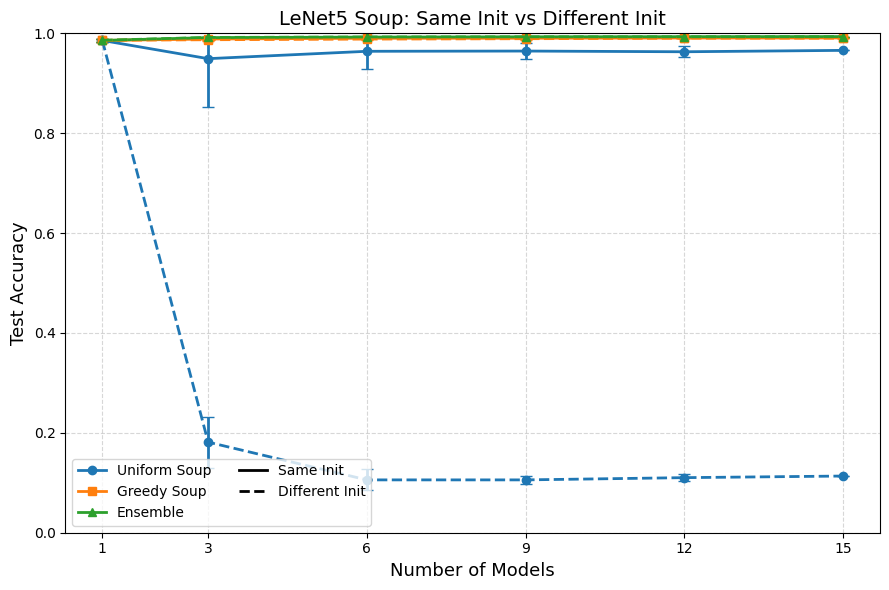

In [35]:
# MNIST (LeNet5) 
plot_soup_comparison(
    same_init_df=mnist_table_same_init, 
    diff_init_df=mnist_table_diff_init, 
    title="LeNet5 Soup: Same Init vs Different Init", 
    save_path="lenet5_soup_result.png",
    ylim=(0, 1)  
)


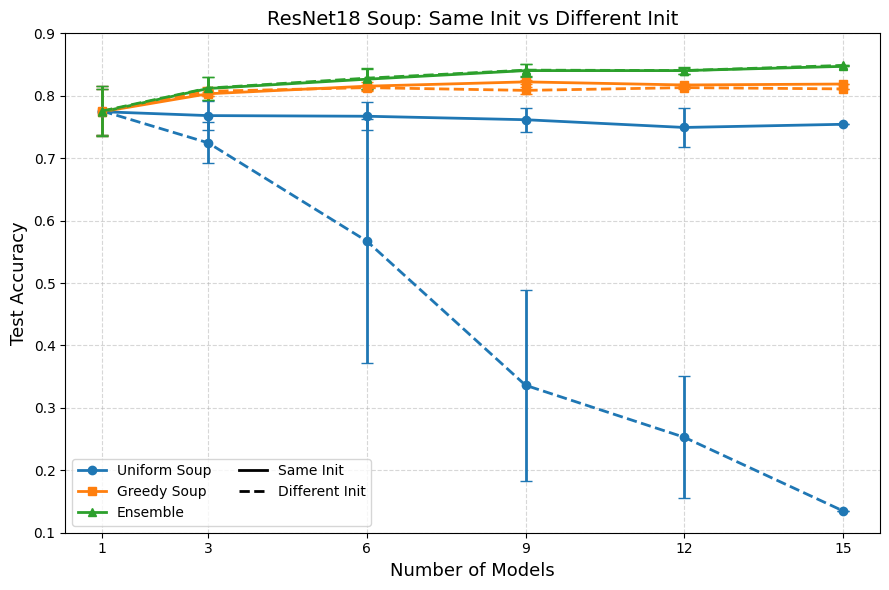

In [36]:
# CIFAR10 (ResNet18) 
plot_soup_comparison(
    same_init_df=cifar_table_same_init, 
    diff_init_df=cifar_table_diff_init, 
    title="ResNet18 Soup: Same Init vs Different Init", 
    save_path="resnet18_soup_result.png",
    ylim=(0.1, 0.90)  
)

## 5 analyse of linear mode connectivity 

### 5.1 fisher information:

In [37]:
# Compute diagonal Fisher Information Matrix approximation.
def compute_fisher(model, data_loader, device, criterion):
    model.eval()
    fisher = {}
    for name, param in model.named_parameters():
        fisher[name] = torch.zeros_like(param)  

    for inputs, labels in data_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        model.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        for name, param in model.named_parameters():
            fisher[name] += param.grad.data ** 2  # 累加grad²

    # Diagonal Fisher Approximation
    for name in fisher:
        fisher[name] /= len(data_loader.dataset)

    return fisher

In [38]:
# Compute cosine similarity between two Fisher Information Matrices.
def fisher_cosine_similarity(fisher1, fisher2):
    # Compute overall similarity 
    # 一个数字，越接近1说明两个模型的Fisher信息越相似，越接近0说明越不相似
    all_f1 = torch.cat([v.flatten() for v in fisher1.values()])
    all_f2 = torch.cat([v.flatten() for v in fisher2.values()])

    fisher_similarity = F.cosine_similarity(
        all_f1, all_f2, dim=0
    ).item()

    return fisher_similarity

In [39]:
def fisher_sim_matrix(models, train_loader, device, criterion):
    # Compute Fisher Information for all models
    fishers = [compute_fisher(model, train_loader, device, criterion) for model in models]
    models_num = len(fishers)

    # Compute serveral pairwise similarities between models
    fisher_sim = np.zeros((models_num, models_num))
    for i in range(models_num):
        for j in range(i + 1, models_num):
            sim = fisher_cosine_similarity(fishers[i], fishers[j])
            fisher_sim[i][j] = sim
            fisher_sim[j][i] = sim

    # 对角线填充为 1.0，表示自身相似度
    np.fill_diagonal(fisher_sim, 1.0)
    return fisher_sim

In [40]:
def fisher_sim_heatmap(fisher_sim):
    fig, ax = plt.subplots(figsize=(8, 6.5))

    model_names = [f'Model {i+1}' for i in range(fisher_sim.shape[0])]
    df_sim = pd.DataFrame(fisher_sim, index=model_names, columns=model_names)
    # 构建下三角 mask
    mask = np.triu(np.ones_like(df_sim, dtype=bool), k=1)  # k=1 保留对角线

    sns.heatmap(
        df_sim,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        vmin=0, vmax=1,
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Fisher Similarity', 'shrink': 0.8},
        ax=ax
    )

    ax.set_title('Model Fisher Similarity (Lower Triangle)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

    plt.tight_layout()
    # plt.savefig('/mnt/data/similarity_heatmap_lower.png', dpi=150, bbox_inches='tight')
    plt.show()


### mnist:

#### different initialization:

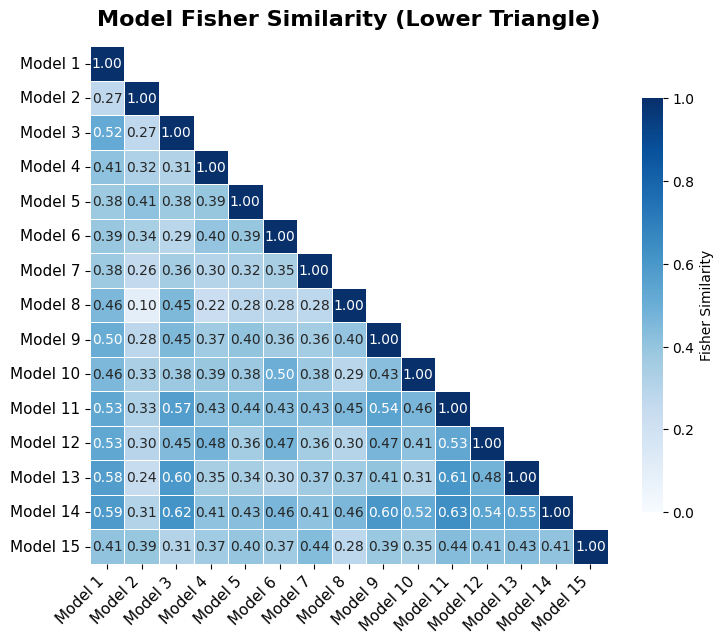

In [41]:
mnist_fisher_sim_matrix_diff_init = fisher_sim_matrix(mnist_result_diff_init["models"], mnist_train_loader, device, criterion=nn.CrossEntropyLoss())
fisher_sim_heatmap(mnist_fisher_sim_matrix_diff_init)

#### same initialization:

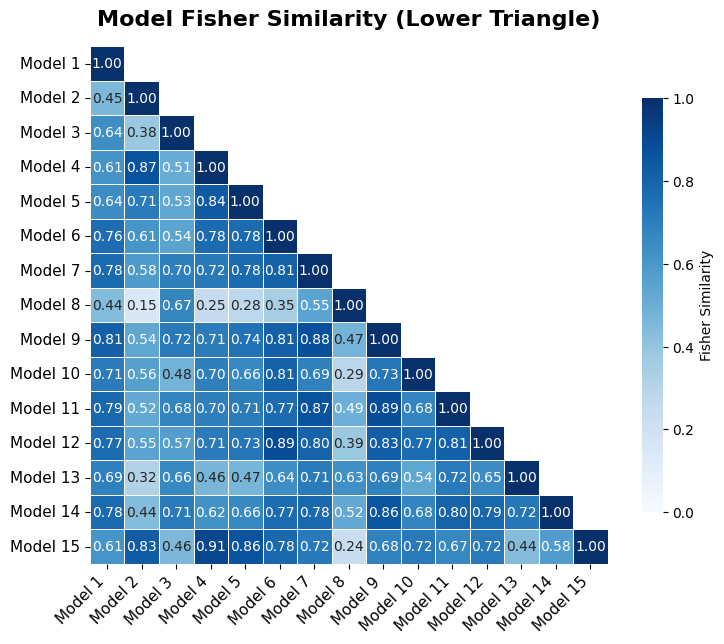

In [42]:
mnist_fisher_sim_matrix_same_init = fisher_sim_matrix(mnist_result_same_init["models"], mnist_train_loader, device, criterion=nn.CrossEntropyLoss())
fisher_sim_heatmap(mnist_fisher_sim_matrix_same_init)

### cifar:

#### different initialization:

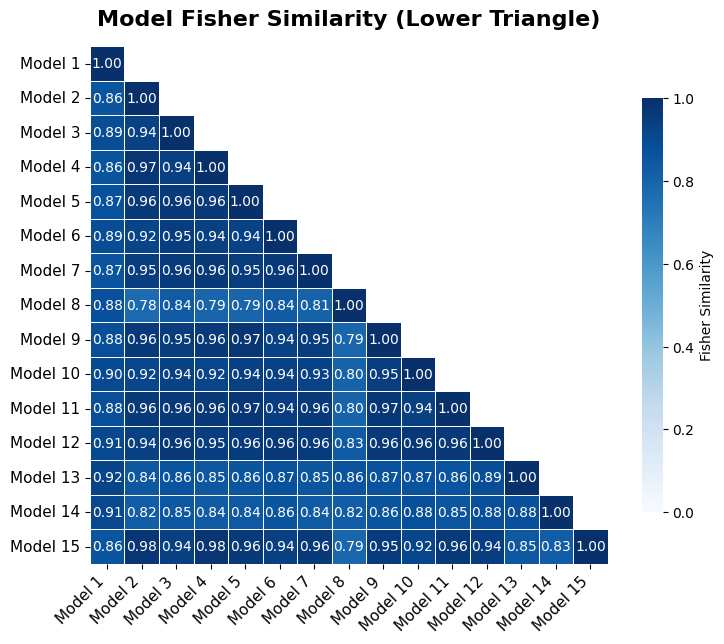

In [43]:
cifar_fisher_sim_matrix_diff_init = fisher_sim_matrix(cifar_result_diff_init["models"], cifar_train_loader, device, criterion=nn.CrossEntropyLoss())
fisher_sim_heatmap(cifar_fisher_sim_matrix_diff_init)

#### same initialization:

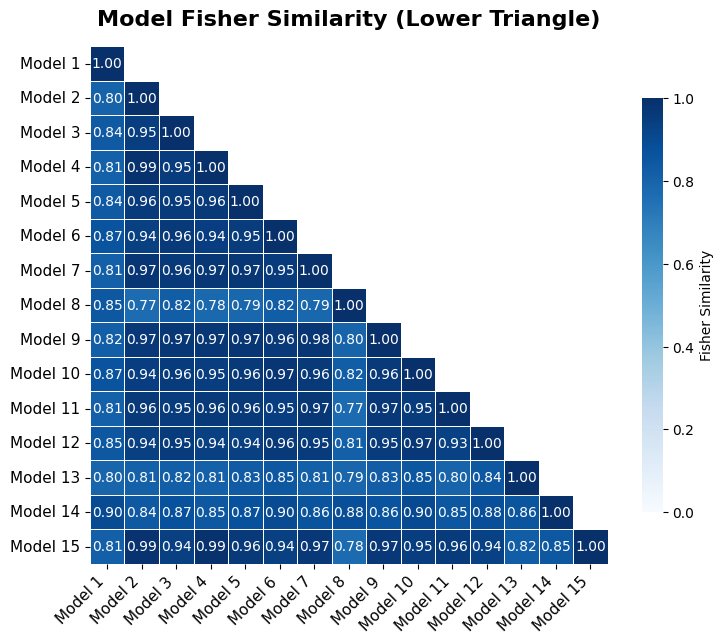

In [44]:
cifar_fisher_sim_matrix_same_init = fisher_sim_matrix(cifar_result_same_init["models"], cifar_train_loader, device, criterion=nn.CrossEntropyLoss())
fisher_sim_heatmap(cifar_fisher_sim_matrix_same_init)

### 5.2 interpolation plot

In [45]:
# 用线性插值法来生成位于一条线上的多个model
def interpolate_models(model_A, model_B, lambdas, model_class, device):
    models = []
    for lam in lambdas:
        model = model_class().to(device)
        state = {}
        for key in model_A.state_dict():
            state[key] = (1 - lam) * model_A.state_dict()[key] + lam * model_B.state_dict()[key]
        model.load_state_dict(state)
        model.to(device)
        model.eval()
        models.append(model)
    return models

In [46]:
# 计算线性插值的valid loss和valid acc
def loss_acc(model_A, model_B, valid_loader, device, lambdas, model_class):
    models = interpolate_models(model_A, model_B, lambdas, model_class, device)
    
    valid_losses = []
    valid_accs = []
    criterion = nn.CrossEntropyLoss()
    
    for model, lam in zip(models, lambdas):
        torch.manual_seed(42) # 
        model.eval()
        total_loss = 0.0
        count = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)
                count += inputs.size(0)
                
        valid_losses.append(total_loss / count)
        
        acc = evaluate(model, valid_loader, device)
        valid_accs.append(acc)
        print(f"λ={lam:.2f}: Valid Loss={valid_losses[-1]:.4f}, Valid Acc={acc:.4f}")

    return valid_losses, valid_accs

In [47]:
#barrier是一个判断两个模型是否在同一个盆地里的指标。
def barrier(valid_losses, lambdas):
    ref_line = [valid_losses[0] + (valid_losses[-1] - valid_losses[0]) * (lam / lambdas[-1]) for lam in lambdas]
    barriers = [valid_losses[i] - ref_line[i] for i in range(len(valid_losses))]
    barrier_value = max(barriers)
    idx = barriers.index(barrier_value)
    return ref_line, barrier_value, idx

In [48]:
# 可视化 线性插值的结果
def plot_interpolation(lambdas, valid_losses, valid_accs, ref_line, barrier_value, barrier_idx, title="Linear Interpolation"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Valid Loss and Reference Line
    ax1.plot(lambdas, valid_losses, 'o-', label='Valid Loss')
    ax1.plot(lambdas, ref_line, 'r-', label='Reference Line')
    ax1.plot([lambdas[barrier_idx], lambdas[barrier_idx]], [ref_line[barrier_idx], valid_losses[barrier_idx]], 'g--', label=f'Barrier Value: {barrier_value:.4f}')
    ax1.set_xlabel('λ')
    ax1.set_ylabel('Valid Loss')
    ax1.set_title("Valid Loss with Barrier")
    ax1.legend(loc='upper right')
    ax1.grid(True)

    # Plot Valid Accuracy
    ax2.plot(lambdas, valid_accs, 's-', color='tab:blue', label='Valid Acc')
    ax2.set_xlabel('λ')
    ax2.set_ylabel('Valid Accuracy')
    ax2.set_title("Valid Accuracy")
    ax2.legend(loc='upper right')
    ax2.grid(True)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [49]:
def find_model_pairs(fisher_sims):
    fisher_sim_max, fisher_sim_min = 0.0, 1.0
    model_pairs_max, model_pairs_min = (0, 0), (0, 0)
    model_num = fisher_sims.shape[0]
    for i in range(model_num):
        for j in range(i+1, model_num):
            if fisher_sims[i][j] > fisher_sim_max:
                fisher_sim_max = fisher_sims[i][j]
                model_pairs_max = (i, j)
            if fisher_sims[i][j] < fisher_sim_min:
                fisher_sim_min = fisher_sims[i][j]
                model_pairs_min = (i, j)
    return model_pairs_max, model_pairs_min

### mnist:

#### different initialization:

In [50]:
mnist_model_pairs_max_diff, mnist_model_pairs_min_diff = find_model_pairs(mnist_fisher_sim_matrix_diff_init)
print(f"max: {mnist_model_pairs_max_diff}")
print(f"min: {mnist_model_pairs_min_diff}")

max: (10, 13)
min: (1, 7)


λ=0.00: Valid Loss=0.0313, Valid Acc=0.9915
λ=0.10: Valid Loss=0.0344, Valid Acc=0.9913
λ=0.20: Valid Loss=0.1288, Valid Acc=0.9865
λ=0.30: Valid Loss=0.6193, Valid Acc=0.9680
λ=0.40: Valid Loss=1.4330, Valid Acc=0.8975
λ=0.50: Valid Loss=1.9079, Valid Acc=0.5947
λ=0.60: Valid Loss=1.8425, Valid Acc=0.5928
λ=0.70: Valid Loss=1.1977, Valid Acc=0.8715
λ=0.80: Valid Loss=0.3482, Valid Acc=0.9742
λ=0.90: Valid Loss=0.0543, Valid Acc=0.9892
λ=1.00: Valid Loss=0.0302, Valid Acc=0.9898


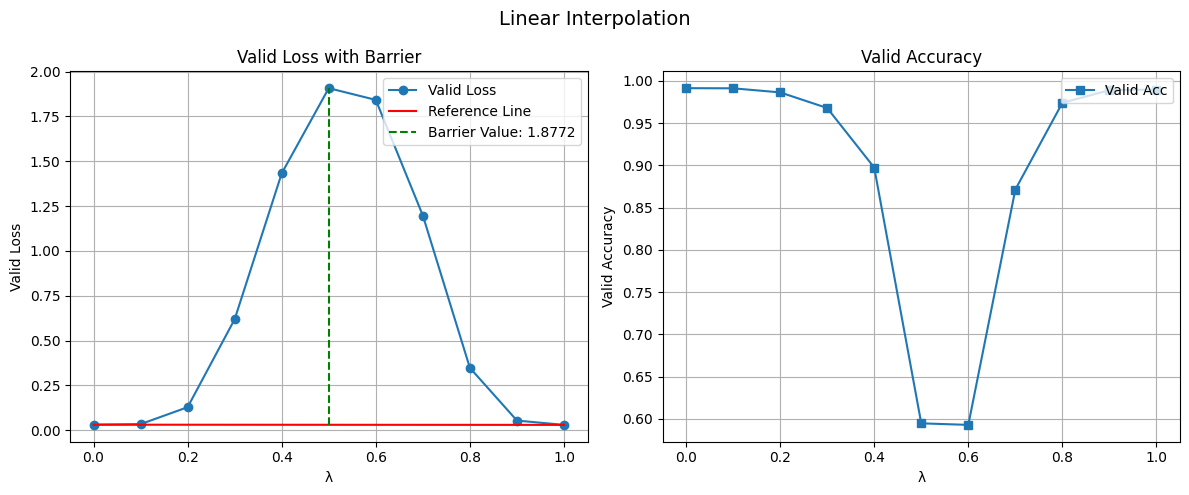

In [51]:
model_max_A = mnist_result_diff_init["models"][mnist_model_pairs_max_diff[0]]
model_max_B = mnist_result_diff_init["models"][mnist_model_pairs_max_diff[1]]

lambdas=np.linspace(0, 1, 11)

mnist_valid_losses, mnist_valid_accs = loss_acc(model_max_A, model_max_B, mnist_valid_loader, device, lambdas, model_class=LeNet5_Caffe)
mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx = barrier(mnist_valid_losses, lambdas)
plot_interpolation(lambdas, mnist_valid_losses, mnist_valid_accs, mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx)

λ=0.00: Valid Loss=0.0657, Valid Acc=0.9792
λ=0.10: Valid Loss=0.6157, Valid Acc=0.8338
λ=0.20: Valid Loss=2.1853, Valid Acc=0.2788
λ=0.30: Valid Loss=2.7269, Valid Acc=0.1530
λ=0.40: Valid Loss=2.5729, Valid Acc=0.1532
λ=0.50: Valid Loss=2.0731, Valid Acc=0.2565
λ=0.60: Valid Loss=1.4283, Valid Acc=0.6463
λ=0.70: Valid Loss=0.5179, Valid Acc=0.9295
λ=0.80: Valid Loss=0.1252, Valid Acc=0.9800
λ=0.90: Valid Loss=0.0592, Valid Acc=0.9852
λ=1.00: Valid Loss=0.0610, Valid Acc=0.9853


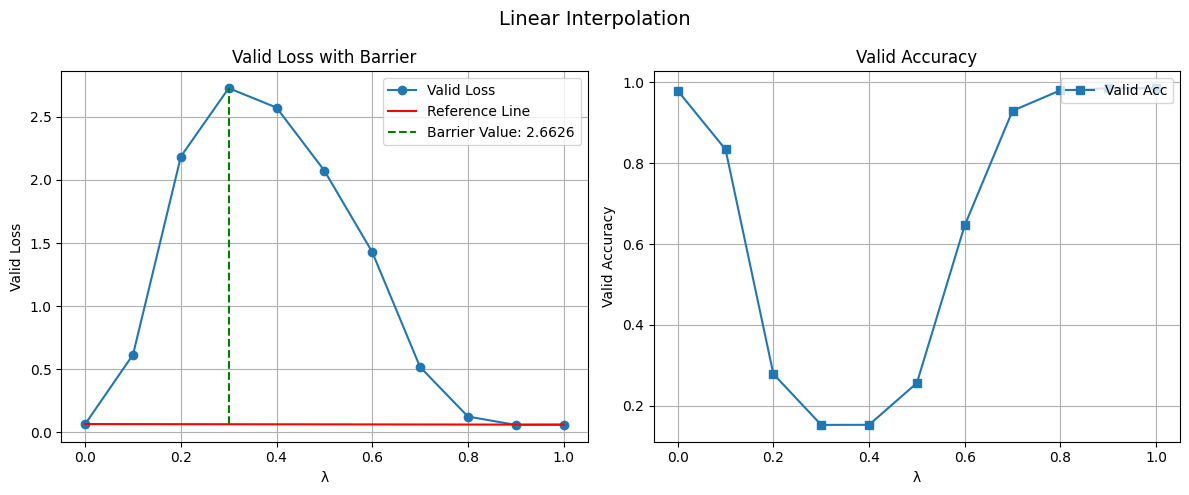

In [52]:
model_min_A = mnist_result_diff_init["models"][mnist_model_pairs_min_diff[0]]
model_min_B = mnist_result_diff_init["models"][mnist_model_pairs_min_diff[1]]

lambdas=np.linspace(0, 1, 11)

mnist_valid_losses, mnist_valid_accs = loss_acc(model_min_A, model_min_B, mnist_valid_loader, device, lambdas, model_class=LeNet5_Caffe)
mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx = barrier(mnist_valid_losses, lambdas)
plot_interpolation(lambdas, mnist_valid_losses, mnist_valid_accs, mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx)

#### same initialization:

In [53]:
mnist_model_pairs_max_same, mnist_model_pairs_min_same = find_model_pairs(mnist_fisher_sim_matrix_same_init)
print(f"max: {mnist_model_pairs_max_same}")
print(f"min: {mnist_model_pairs_min_same}")

max: (3, 14)
min: (1, 7)


λ=0.00: Valid Loss=0.0469, Valid Acc=0.9843
λ=0.10: Valid Loss=0.0477, Valid Acc=0.9838
λ=0.20: Valid Loss=0.0493, Valid Acc=0.9835
λ=0.30: Valid Loss=0.0515, Valid Acc=0.9837
λ=0.40: Valid Loss=0.0533, Valid Acc=0.9832
λ=0.50: Valid Loss=0.0537, Valid Acc=0.9830
λ=0.60: Valid Loss=0.0525, Valid Acc=0.9835
λ=0.70: Valid Loss=0.0501, Valid Acc=0.9847
λ=0.80: Valid Loss=0.0473, Valid Acc=0.9853
λ=0.90: Valid Loss=0.0450, Valid Acc=0.9855
λ=1.00: Valid Loss=0.0434, Valid Acc=0.9860


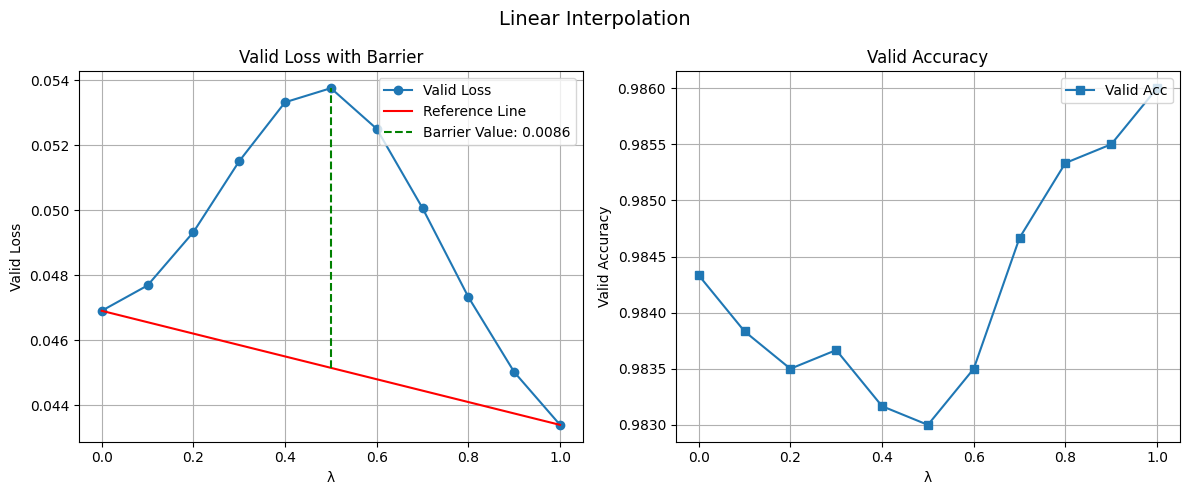

In [54]:
model_max_A = mnist_result_same_init["models"][mnist_model_pairs_max_same[0]]
model_max_B = mnist_result_same_init["models"][mnist_model_pairs_max_same[1]]

lambdas=np.linspace(0, 1, 11)

mnist_valid_losses, mnist_valid_accs = loss_acc(model_max_A, model_max_B, mnist_valid_loader, device, lambdas, model_class=LeNet5_Caffe)
mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx = barrier(mnist_valid_losses, lambdas)
plot_interpolation(lambdas, mnist_valid_losses, mnist_valid_accs, mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx)

λ=0.00: Valid Loss=0.0576, Valid Acc=0.9813
λ=0.10: Valid Loss=0.3489, Valid Acc=0.9228
λ=0.20: Valid Loss=1.2898, Valid Acc=0.7210
λ=0.30: Valid Loss=1.6882, Valid Acc=0.5950
λ=0.40: Valid Loss=1.4659, Valid Acc=0.6913
λ=0.50: Valid Loss=0.9016, Valid Acc=0.8343
λ=0.60: Valid Loss=0.4196, Valid Acc=0.9220
λ=0.70: Valid Loss=0.1825, Valid Acc=0.9658
λ=0.80: Valid Loss=0.0985, Valid Acc=0.9778
λ=0.90: Valid Loss=0.0804, Valid Acc=0.9812
λ=1.00: Valid Loss=0.0854, Valid Acc=0.9835


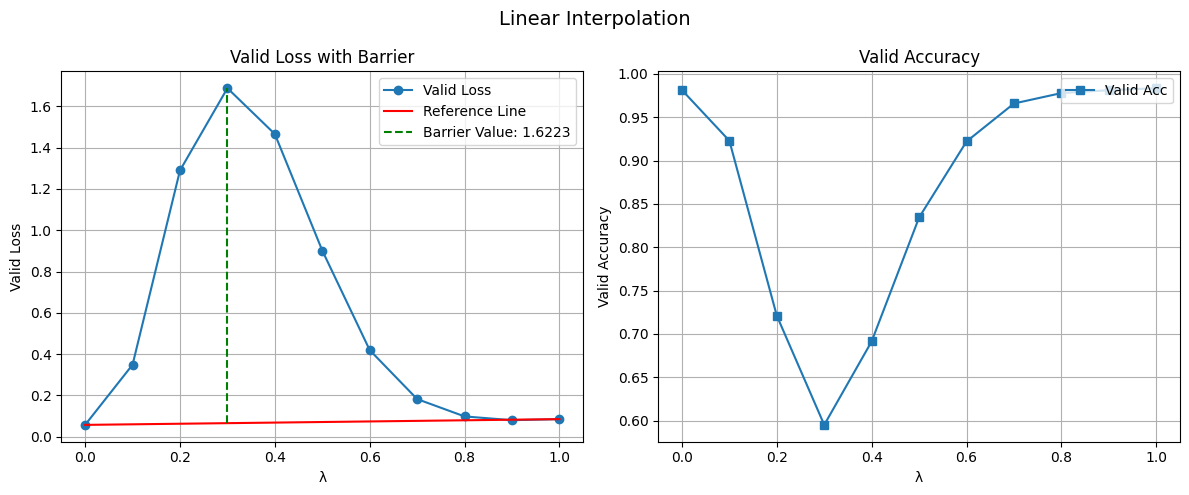

In [55]:
model_min_A = mnist_result_same_init["models"][mnist_model_pairs_min_same[0]]
model_min_B = mnist_result_same_init["models"][mnist_model_pairs_min_same[1]]

lambdas=np.linspace(0, 1, 11)

mnist_valid_losses, mnist_valid_accs = loss_acc(model_min_A, model_min_B, mnist_valid_loader, device, lambdas, model_class=LeNet5_Caffe)
mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx = barrier(mnist_valid_losses, lambdas)
plot_interpolation(lambdas, mnist_valid_losses, mnist_valid_accs, mnist_barrier_ref, mnist_barrier_value, mnist_barrier_idx)

### cifar:

#### different initialization:

In [56]:
cifar_model_pairs_max_diff, cifar_model_pairs_min_diff = find_model_pairs(cifar_fisher_sim_matrix_diff_init)
print(f"max: {cifar_model_pairs_max_diff}")
print(f"min: {cifar_model_pairs_min_diff}")

max: (3, 14)
min: (1, 7)


λ=0.00: Valid Loss=0.8836, Valid Acc=0.7006
λ=0.10: Valid Loss=0.8891, Valid Acc=0.6930
λ=0.20: Valid Loss=0.9179, Valid Acc=0.6888
λ=0.30: Valid Loss=0.9578, Valid Acc=0.6844
λ=0.40: Valid Loss=0.9927, Valid Acc=0.6786
λ=0.50: Valid Loss=1.0073, Valid Acc=0.6790
λ=0.60: Valid Loss=0.9948, Valid Acc=0.6828
λ=0.70: Valid Loss=0.9600, Valid Acc=0.6874
λ=0.80: Valid Loss=0.9179, Valid Acc=0.6908
λ=0.90: Valid Loss=0.8855, Valid Acc=0.6950
λ=1.00: Valid Loss=0.8747, Valid Acc=0.6992


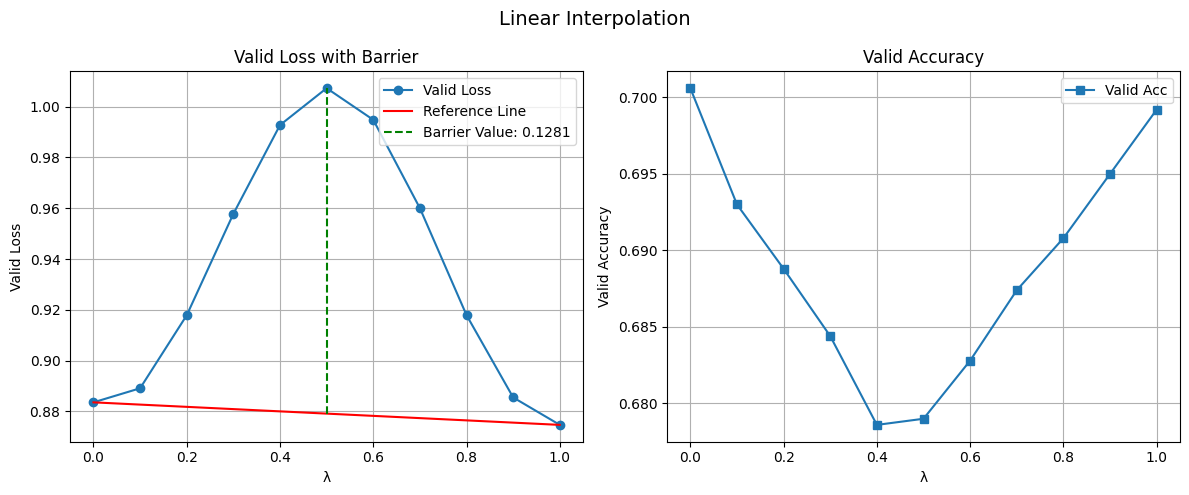

In [57]:
model_max_A = cifar_result_diff_init["models"][cifar_model_pairs_max_diff[0]]
model_max_B = cifar_result_diff_init["models"][cifar_model_pairs_max_diff[1]]

lambdas=np.linspace(0, 1, 11)

cifar_valid_losses, cifar_valid_accs = loss_acc(model_max_A, model_max_B, cifar_valid_loader, device, lambdas, model_class=ResNet18)
cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx = barrier(cifar_valid_losses, lambdas)
plot_interpolation(lambdas, cifar_valid_losses, cifar_valid_accs, cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx)

λ=0.00: Valid Loss=0.8715, Valid Acc=0.6958
λ=0.10: Valid Loss=2.0984, Valid Acc=0.2788
λ=0.20: Valid Loss=2.1513, Valid Acc=0.3262
λ=0.30: Valid Loss=2.0244, Valid Acc=0.5452
λ=0.40: Valid Loss=1.7569, Valid Acc=0.7118
λ=0.50: Valid Loss=1.3831, Valid Acc=0.7794
λ=0.60: Valid Loss=1.0081, Valid Acc=0.7972
λ=0.70: Valid Loss=0.7404, Valid Acc=0.8064
λ=0.80: Valid Loss=0.6085, Valid Acc=0.8064
λ=0.90: Valid Loss=0.5818, Valid Acc=0.8054
λ=1.00: Valid Loss=0.6271, Valid Acc=0.8010


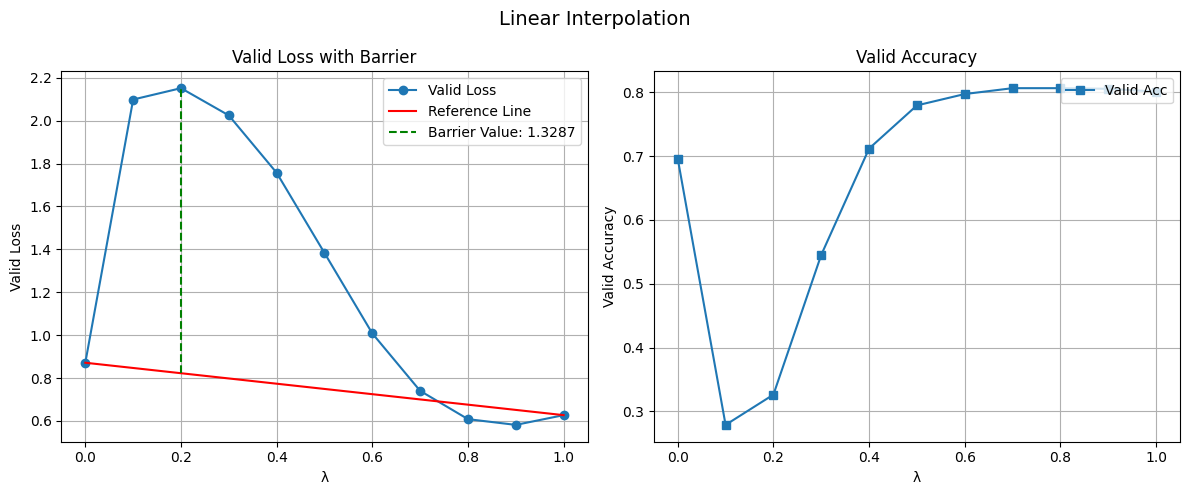

In [58]:
model_min_A = cifar_result_diff_init["models"][cifar_model_pairs_min_diff[0]]
model_min_B = cifar_result_diff_init["models"][cifar_model_pairs_min_diff[1]]

lambdas=np.linspace(0, 1, 11)

cifar_valid_losses, cifar_valid_accs = loss_acc(model_min_A, model_min_B, cifar_valid_loader, device, lambdas, model_class=ResNet18)
cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx = barrier(cifar_valid_losses, lambdas)
plot_interpolation(lambdas, cifar_valid_losses, cifar_valid_accs, cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx)

#### same initialization:

In [59]:
cifar_model_pairs_max_same, cifar_model_pairs_min_same = find_model_pairs(cifar_fisher_sim_matrix_same_init)
print(f"max: {cifar_model_pairs_max_same}")
print(f"min: {cifar_model_pairs_min_same}")

max: (1, 3)
min: (1, 7)


λ=0.00: Valid Loss=0.8745, Valid Acc=0.7020
λ=0.10: Valid Loss=0.8726, Valid Acc=0.7032
λ=0.20: Valid Loss=0.8713, Valid Acc=0.7022
λ=0.30: Valid Loss=0.8705, Valid Acc=0.7038
λ=0.40: Valid Loss=0.8702, Valid Acc=0.7032
λ=0.50: Valid Loss=0.8704, Valid Acc=0.7018
λ=0.60: Valid Loss=0.8707, Valid Acc=0.7040
λ=0.70: Valid Loss=0.8712, Valid Acc=0.7032
λ=0.80: Valid Loss=0.8722, Valid Acc=0.7030
λ=0.90: Valid Loss=0.8737, Valid Acc=0.7032
λ=1.00: Valid Loss=0.8757, Valid Acc=0.7018


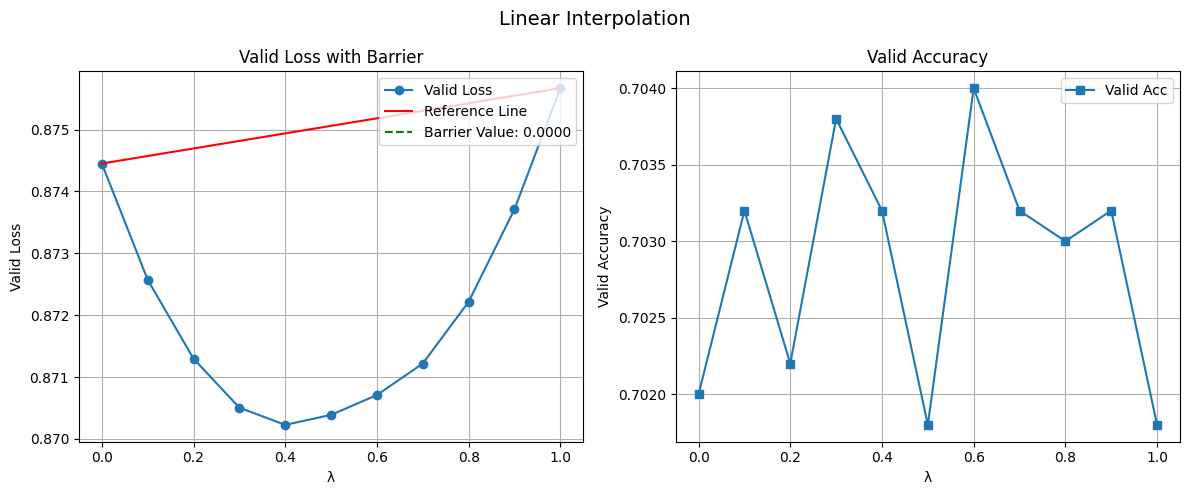

In [60]:
model_max_A = cifar_result_same_init["models"][cifar_model_pairs_max_same[0]]
model_max_B = cifar_result_same_init["models"][cifar_model_pairs_max_same[1]]

lambdas=np.linspace(0, 1, 11)

cifar_valid_losses, cifar_valid_accs = loss_acc(model_max_A, model_max_B, cifar_valid_loader, device, lambdas, model_class=ResNet18)
cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx = barrier(cifar_valid_losses, lambdas)
plot_interpolation(lambdas, cifar_valid_losses, cifar_valid_accs, cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx)

λ=0.00: Valid Loss=0.8745, Valid Acc=0.7020
λ=0.10: Valid Loss=2.0480, Valid Acc=0.4884
λ=0.20: Valid Loss=2.0316, Valid Acc=0.5416
λ=0.30: Valid Loss=1.8206, Valid Acc=0.6942
λ=0.40: Valid Loss=1.4754, Valid Acc=0.7582
λ=0.50: Valid Loss=1.0945, Valid Acc=0.7840
λ=0.60: Valid Loss=0.7964, Valid Acc=0.7984
λ=0.70: Valid Loss=0.6300, Valid Acc=0.8054
λ=0.80: Valid Loss=0.5700, Valid Acc=0.8110
λ=0.90: Valid Loss=0.5791, Valid Acc=0.8110
λ=1.00: Valid Loss=0.6355, Valid Acc=0.8046


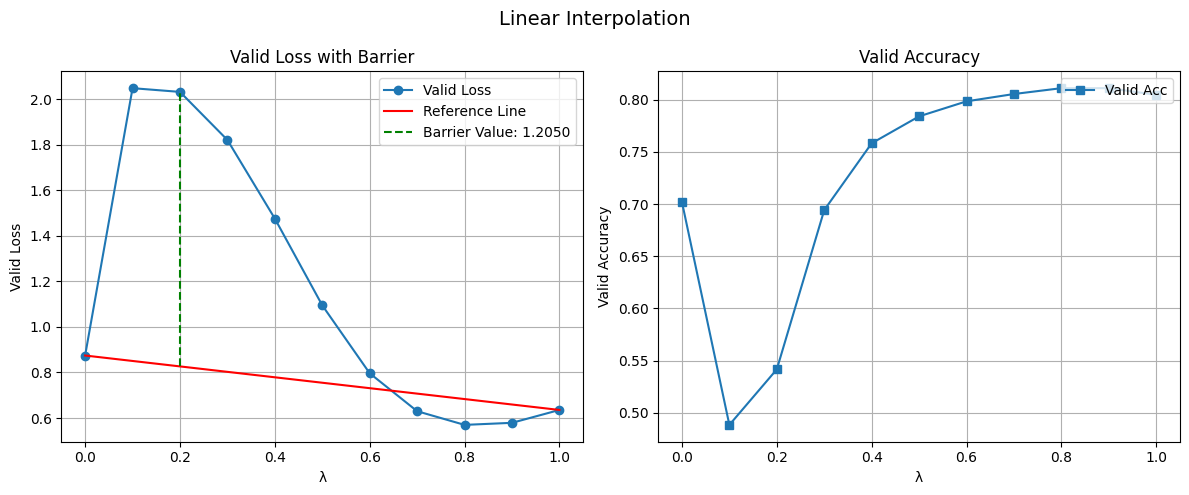

In [61]:
model_min_A = cifar_result_same_init["models"][cifar_model_pairs_min_same[0]]
model_min_B = cifar_result_same_init["models"][cifar_model_pairs_min_same[1]]

lambdas=np.linspace(0, 1, 11)

cifar_valid_losses, cifar_valid_accs = loss_acc(model_min_A, model_min_B, cifar_valid_loader, device, lambdas, model_class=ResNet18)
cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx = barrier(cifar_valid_losses, lambdas)
plot_interpolation(lambdas, cifar_valid_losses, cifar_valid_accs, cifar_barrier_ref, cifar_barrier_value, cifar_barrier_idx)

### 5.3 uniform soup for adding models progressively

In [62]:
def find_add_model(fisher_sims, model_idx_list):
    model_num = fisher_sims.shape[0]
    model_sim = {}
    for i in range(model_num):
        if i in model_idx_list:
            continue
        for j in model_idx_list:
            model_sim[i] = model_sim.get(i, 0.0) + fisher_sims[i][j]
    add_model_idx = max(model_sim, key=model_sim.get) # type: ignore
    model_idx_list.append(add_model_idx)
    return model_idx_list

In [63]:
def add_uniform_soup(model_max_list, max_model_num, fisher_sim_matrix, models, test_loader, device):
    while len(model_max_list) <= max_model_num:
        uniform_soup_model = uniform_soup([models[i] for i in model_max_list]) # type: ignore
        uniform_soup_test_acc = evaluate(uniform_soup_model, test_loader, device)
        print(f"Uniform Soup test accuracy({model_max_list}): {uniform_soup_test_acc:.4f}")
        model_max_list = find_add_model(fisher_sim_matrix, model_max_list)

### mnist:

In [64]:
# different initialization:
max_model_num = 5
add_uniform_soup(list(mnist_model_pairs_max_diff), max_model_num, mnist_fisher_sim_matrix_diff_init, mnist_result_diff_init["models"], mnist_test_loader, device)

Uniform Soup test accuracy([10, 13]): 0.5954
Uniform Soup test accuracy([10, 13, 2]): 0.0974
Uniform Soup test accuracy([10, 13, 2, 12]): 0.0974
Uniform Soup test accuracy([10, 13, 2, 12, 0]): 0.0974


In [65]:
# same initialization:
max_model_num = 5
add_uniform_soup(list(mnist_model_pairs_max_same), max_model_num, mnist_fisher_sim_matrix_same_init, mnist_result_same_init["models"], mnist_test_loader, device)

Uniform Soup test accuracy([3, 14]): 0.9830
Uniform Soup test accuracy([3, 14, 4]): 0.9830
Uniform Soup test accuracy([3, 14, 4, 1]): 0.9812
Uniform Soup test accuracy([3, 14, 4, 1, 5]): 0.9843


### cifar10:

In [66]:
# different initialization:
max_model_num = 5
add_uniform_soup(list(cifar_model_pairs_max_diff), max_model_num, cifar_fisher_sim_matrix_diff_init, cifar_result_diff_init["models"], cifar_test_loader, device)

Uniform Soup test accuracy([3, 14]): 0.6916
Uniform Soup test accuracy([3, 14, 1]): 0.6660
Uniform Soup test accuracy([3, 14, 1, 10]): 0.6768
Uniform Soup test accuracy([3, 14, 1, 10, 4]): 0.6767


In [67]:
# same initialization:
max_model_num = 5
add_uniform_soup(list(cifar_model_pairs_max_same), max_model_num, cifar_fisher_sim_matrix_same_init, cifar_result_same_init["models"], cifar_test_loader, device)

Uniform Soup test accuracy([1, 3]): 0.7059
Uniform Soup test accuracy([1, 3, 14]): 0.7042
Uniform Soup test accuracy([1, 3, 14, 6]): 0.7313
Uniform Soup test accuracy([1, 3, 14, 6, 8]): 0.7480
